# Product Experimentation & Conversion Optimization

### Author

 **Abhirami Ananthakumar**

Data Analyst | Business Intelligence | Data Analytics

**GitHub:** [Abhirami Ananthakumar](https://github.com/abhirami-ananthakumar)  
**LinkedIn:** [Abhirami Ananthakumar](https://www.linkedin.com/in/abhirami-ananthakumar-8b83a5256)

---

## Business Problem

An online company is testing an advertising campaign to determine whether showing advertisements increases user conversion.

Users were randomly assigned to one of two experiment groups:

- **Treatment group (`ad`)** — users were exposed to advertisements.
- **Control group (`psa`)** — users were shown a public service announcement instead.

The company wants to determine whether the advertising campaign produces a meaningful improvement in conversion.

## Primary Business Question

> **Should the company continue or scale the advertising campaign?**

## Analytical Objectives

1. Validate the quality and structure of the experiment data.
2. Compare conversion rates between the treatment and control groups.
3. Measure absolute and relative conversion uplift.
4. Test whether the observed difference is statistically significant.
5. Estimate the confidence interval for the treatment effect.
6. Evaluate whether the improvement is practically meaningful from a business perspective.
7. Analyze conversion patterns across advertising exposure and user activity.
8. Provide a clear business recommendation.

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Statsmodels

## Key Decision Framework

The campaign will not be recommended for scaling based on statistical significance alone.

The final recommendation will consider:

**Statistical significance + Effect size + Business significance + Campaign economics**

In [2]:
import sys
print (sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("../01_Dataset/marketing_AB.csv")

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## 1. Dataset Inspection

Before cleaning the data, we inspect its structure, dimensions, data types, missing values, duplicate records, and categorical values.

The objective is to understand the dataset and identify potential data-quality issues before performing any statistical analysis.

In [ ]:

# ============================================
# 1. DATASET INSPECTION
# ============================================

# 1.1 Dataset dimensions
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# 1.2 Column names and data types
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

# 1.3 Missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

# 1.4 Duplicate rows
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Duplicate rows: {df.duplicated().sum():,}")

# 1.5 Unique values in key experiment columns
print("\n" + "=" * 60)
print("EXPERIMENT GROUP DISTRIBUTION")
print("=" * 60)
print(df["test group"].value_counts())

print("\n" + "=" * 60)
print("CONVERSION DISTRIBUTION")
print("=" * 60)
print(df["converted"].value_counts())

print("\n" + "=" * 60)
print("MOST ADS — DAY")
print("=" * 60)
print(df["most ads day"].value_counts())

print("\n" + "=" * 60)
print("MOST ADS — HOUR")
print("=" * 60)
print(df["most ads hour"].value_counts().sort_index())

# 1.6 Statistical summary
print("\n" + "=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)
display(df.describe())

DATASET DIMENSIONS
Rows    : 588,101
Columns : 7

DATA TYPES
Unnamed: 0       int64
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

MISSING VALUES
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

DUPLICATE ROWS
Duplicate rows: 0

EXPERIMENT GROUP DISTRIBUTION
test group
ad     564577
psa     23524
Name: count, dtype: int64

CONVERSION DISTRIBUTION
converted
False    573258
True      14843
Name: count, dtype: int64

MOST ADS — DAY
most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

MOST ADS — HOUR
most ads hour
0      5536
1      4802
2      5333
3      2679
4       722
5       765
6      2068
7      6405
8     17627
9     31004
10    38939
11    46210
12    47298
13  

,Unnamed: 0,user id,total ads,most ads hour
count,"588,101.0000","588,101.0000","588,101.0000","588,101.0000"
mean,"294,050.0000","1,310,692.2158",24.8209,14.4691
std,"169,770.2797","202,225.9831",43.7152,4.8346
min,0.0000,"900,000.0000",1.0000,0.0000
25%,"147,025.0000","1,143,190.0000",4.0000,11.0000
50%,"294,050.0000","1,313,725.0000",13.0000,14.0000
75%,"441,075.0000","1,484,088.0000",27.0000,18.0000
max,"588,100.0000","1,654,483.0000","2,065.0000",23.0000


## 2. Data Quality Validation

Before making any changes to the dataset, we validate the experiment data for potential quality issues.

The validation focuses on:

- User ID uniqueness
- Integrity of the exported index column
- Valid experiment groups
- Valid conversion values
- Valid advertising exposure values
- Valid advertising hours
- Valid day values

The purpose is to identify issues that could affect the reliability of the A/B test before creating the cleaned analytical dataset.

In [ ]:
# ============================================
# 2. DATA QUALITY VALIDATION
# ============================================

# ------------------------------------------------------------
# 2.1 USER ID UNIQUENESS
# ------------------------------------------------------------
print("=" * 60)
print("USER ID UNIQUENESS")
print("=" * 60)

print(f"Unique user IDs : {df['user id'].nunique():,}")
print(f"Total rows      : {len(df):,}")
print(f"Duplicate users : {df['user id'].duplicated().sum():,}")


# ------------------------------------------------------------
# 2.2 INDEX COLUMN VALIDATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("INDEX COLUMN VALIDATION")
print("=" * 60)

index_matches = (df["Unnamed: 0"] == np.arange(len(df))).all()

print(f"Unnamed: 0 matches row index: {index_matches}")
print(f"Unique values in Unnamed: 0 : {df['Unnamed: 0'].nunique():,}")


# ------------------------------------------------------------
# 2.3 EXPERIMENT GROUP VALIDATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("EXPERIMENT GROUP VALIDATION")
print("=" * 60)

print("Unique groups:", df["test group"].unique())
print("Unexpected groups:",
      set(df["test group"].unique()) - {"ad", "psa"})


# ------------------------------------------------------------
# 2.4 CONVERSION VALIDATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("CONVERSION VALIDATION")
print("=" * 60)

print("Unique conversion values:", df["converted"].unique())
print("Missing conversions:", df["converted"].isnull().sum())


# ------------------------------------------------------------
# 2.5 TOTAL ADS VALIDATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TOTAL ADS VALIDATION")
print("=" * 60)

print(f"Minimum ads : {df['total ads'].min():,}")
print(f"Maximum ads : {df['total ads'].max():,}")
print(f"Zero ads    : {(df['total ads'] == 0).sum():,}")
print(f"Negative ads: {(df['total ads'] < 0).sum():,}")


# ------------------------------------------------------------
# 2.6 HOUR VALIDATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("AD HOUR VALIDATION")
print("=" * 60)

print(f"Minimum hour: {df['most ads hour'].min()}")
print(f"Maximum hour: {df['most ads hour'].max()}")

invalid_hours = df[
    ~df["most ads hour"].between(0, 23)
]

print(f"Invalid hours: {len(invalid_hours):,}")


# ------------------------------------------------------------
# 2.7 DAY VALIDATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("DAY VALIDATION")
print("=" * 60)

valid_days = {
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
}

print("Days found:")
print(sorted(df["most ads day"].unique()))

invalid_days = df[
    ~df["most ads day"].isin(valid_days)
]

print(f"Invalid days: {len(invalid_days):,}")

USER ID UNIQUENESS
Unique user IDs : 588,101
Total rows      : 588,101
Duplicate users : 0

INDEX COLUMN VALIDATION
Unnamed: 0 matches row index: True
Unique values in Unnamed: 0 : 588,101

EXPERIMENT GROUP VALIDATION
Unique groups: <StringArray>
['ad', 'psa']
Length: 2, dtype: str
Unexpected groups: set()

CONVERSION VALIDATION
Unique conversion values: [False  True]
Missing conversions: 0

TOTAL ADS VALIDATION
Minimum ads : 1
Maximum ads : 2,065
Zero ads    : 0
Negative ads: 0

AD HOUR VALIDATION
Minimum hour: 0
Maximum hour: 23
Invalid hours: 0

DAY VALIDATION
Days found:
['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Invalid days: 0


## 3. Data Cleaning

This section prepares the validated dataset for exploratory analysis and A/B testing.

Cleaning steps:
- Remove the unnecessary index column
- Standardize column names
- Remove duplicate records if any
- Standardize categorical values
- Validate data types
- Verify final dataset quality
- Save the cleaned dataset

In [8]:
# ============================================================
# 3. DATA CLEANING
# ============================================================

# ------------------------------------------------------------
# 3.1 CREATE CLEAN COPY
# ------------------------------------------------------------

clean_df = df.copy()

print("=" * 60)
print("DATA CLEANING STARTED")
print("=" * 60)

print(f"Original rows    : {len(clean_df):,}")
print(f"Original columns : {clean_df.shape[1]}")


# ------------------------------------------------------------
# 3.2 REMOVE UNNECESSARY INDEX COLUMN
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("REMOVE UNNECESSARY INDEX COLUMN")
print("=" * 60)

if "Unnamed: 0" in clean_df.columns:
    clean_df = clean_df.drop(columns=["Unnamed: 0"])
    print("Removed column: Unnamed: 0")
else:
    print("Unnamed: 0 column not found")


# ------------------------------------------------------------
# 3.3 STANDARDIZE COLUMN NAMES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STANDARDIZE COLUMN NAMES")
print("=" * 60)

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Final column names:")
print(clean_df.columns.tolist())


# ------------------------------------------------------------
# 3.4 REMOVE DUPLICATE RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE RECORD VALIDATION")
print("=" * 60)

duplicates_before = clean_df.duplicated().sum()

print(f"Duplicate rows found: {duplicates_before:,}")

if duplicates_before > 0:
    clean_df = clean_df.drop_duplicates()
    print(f"Duplicate rows removed: {duplicates_before:,}")
else:
    print("No duplicate rows removed")


# ------------------------------------------------------------
# 3.5 STANDARDIZE CATEGORICAL VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STANDARDIZE CATEGORICAL VALUES")
print("=" * 60)

clean_df["test_group"] = (
    clean_df["test_group"]
    .astype(str)
    .str.strip()
    .str.lower()
)

clean_df["converted"] = (
    clean_df["converted"]
    .astype(bool)
)

clean_df["most_ads_day"] = (
    clean_df["most_ads_day"]
    .astype(str)
    .str.strip()
)

print("Test groups:")
print(clean_df["test_group"].unique())

print("\nConversion values:")
print(clean_df["converted"].unique())


# ------------------------------------------------------------
# 3.6 ENSURE NUMERIC DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPE STANDARDIZATION")
print("=" * 60)

clean_df["user_id"] = pd.to_numeric(
    clean_df["user_id"],
    errors="coerce"
)

clean_df["total_ads"] = pd.to_numeric(
    clean_df["total_ads"],
    errors="coerce"
)

clean_df["most_ads_hour"] = pd.to_numeric(
    clean_df["most_ads_hour"],
    errors="coerce"
)

print(clean_df.dtypes)


# ------------------------------------------------------------
# 3.7 CHECK FOR MISSING VALUES AFTER CLEANING
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

missing_values = clean_df.isnull().sum()

print(missing_values)

print(
    f"\nTotal missing values: "
    f"{missing_values.sum():,}"
)


# ------------------------------------------------------------
# 3.8 CHECK BUSINESS LOGIC
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BUSINESS LOGIC VALIDATION")
print("=" * 60)

invalid_ads = (clean_df["total_ads"] < 0).sum()

invalid_hours = (
    (clean_df["most_ads_hour"] < 0) |
    (clean_df["most_ads_hour"] > 23)
).sum()

invalid_groups = (
    ~clean_df["test_group"].isin(["ad", "psa"])
).sum()

valid_days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

invalid_days = (
    ~clean_df["most_ads_day"].isin(valid_days)
).sum()

print(f"Negative ad counts : {invalid_ads:,}")
print(f"Invalid ad hours   : {invalid_hours:,}")
print(f"Invalid groups     : {invalid_groups:,}")
print(f"Invalid days       : {invalid_days:,}")


# ------------------------------------------------------------
# 3.9 FINAL DATASET CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CLEAN DATASET")
print("=" * 60)

print(f"Rows    : {len(clean_df):,}")
print(f"Columns : {clean_df.shape[1]}")

print("\nColumns:")
print(clean_df.columns.tolist())

print("\nFirst 5 rows:")
display(clean_df.head())


# ------------------------------------------------------------
# 3.10 SAVE CLEANED DATASET
# ------------------------------------------------------------

cleaned_file = "../01_Dataset/marketing_AB_cleaned.csv"

clean_df.to_csv(
    cleaned_file,
    index=False
)

print("\n" + "=" * 60)
print("CLEANED DATASET SAVED")
print("=" * 60)

print(f"File: {cleaned_file}")

print("\nDATA CLEANING COMPLETED SUCCESSFULLY")

DATA CLEANING STARTED
Original rows    : 588,101
Original columns : 7

REMOVE UNNECESSARY INDEX COLUMN
Removed column: Unnamed: 0

STANDARDIZE COLUMN NAMES
Final column names:
['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']

DUPLICATE RECORD VALIDATION
Duplicate rows found: 0
No duplicate rows removed

STANDARDIZE CATEGORICAL VALUES
Test groups:
<StringArray>
['ad', 'psa']
Length: 2, dtype: str

Conversion values:
[False  True]

DATA TYPE STANDARDIZATION
user_id          int64
test_group         str
converted         bool
total_ads        int64
most_ads_day       str
most_ads_hour    int64
dtype: object

MISSING VALUE CHECK
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

Total missing values: 0

BUSINESS LOGIC VALIDATION
Negative ad counts : 0
Invalid ad hours   : 0
Invalid groups     : 0
Invalid days       : 0

FINAL CLEAN DATASET
Rows    : 588,101
Columns : 6

Columns:

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14



CLEANED DATASET SAVED
File: ../01_Dataset/marketing_AB_cleaned.csv

DATA CLEANING COMPLETED SUCCESSFULLY


## 4. Exploratory Data Analysis

This section explores user conversion behavior, experiment group performance,
ad exposure, and advertising patterns across days and hours.

Objectives:
- Understand overall conversion behavior
- Compare Ad and PSA groups
- Analyze ad exposure
- Identify high-activity days and hours
- Prepare insights for statistical A/B testing

In [9]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 4.1 OVERALL CONVERSION OVERVIEW
# ------------------------------------------------------------

print("=" * 60)
print("4.1 OVERALL CONVERSION OVERVIEW")
print("=" * 60)

total_users = len(clean_df)
converted_users = clean_df["converted"].sum()
non_converted_users = (~clean_df["converted"]).sum()
overall_conversion_rate = converted_users / total_users

print(f"Total users          : {total_users:,}")
print(f"Converted users      : {converted_users:,}")
print(f"Non-converted users  : {non_converted_users:,}")
print(f"Overall conversion   : {overall_conversion_rate:.2%}")


# ------------------------------------------------------------
# 4.2 CONVERSION BY EXPERIMENT GROUP
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.2 CONVERSION BY EXPERIMENT GROUP")
print("=" * 60)

group_summary = (
    clean_df
    .groupby("test_group")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        total_ads=("total_ads", "sum")
    )
)

group_summary["conversion_rate"] = (
    group_summary["conversions"] /
    group_summary["users"]
)

group_summary["conversion_rate_pct"] = (
    group_summary["conversion_rate"] * 100
)

display(group_summary)


# ------------------------------------------------------------
# 4.3 EXPERIMENT GROUP DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.3 EXPERIMENT GROUP DISTRIBUTION")
print("=" * 60)

group_distribution = (
    clean_df["test_group"]
    .value_counts()
    .to_frame("users")
)

group_distribution["percentage"] = (
    group_distribution["users"] /
    len(clean_df) * 100
)

display(group_distribution)


# ------------------------------------------------------------
# 4.4 AD EXPOSURE ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.4 AD EXPOSURE ANALYSIS")
print("=" * 60)

print(f"Average ads per user : {clean_df['total_ads'].mean():.2f}")
print(f"Median ads per user  : {clean_df['total_ads'].median():.2f}")
print(f"Minimum ads          : {clean_df['total_ads'].min():,}")
print(f"Maximum ads          : {clean_df['total_ads'].max():,}")

ads_by_group = (
    clean_df
    .groupby("test_group")["total_ads"]
    .agg(["mean", "median", "min", "max"])
)

display(ads_by_group)


# ------------------------------------------------------------
# 4.5 CONVERSION BY AD EXPOSURE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.5 CONVERSION BY AD EXPOSURE")
print("=" * 60)

clean_df["ad_exposure_level"] = pd.cut(
    clean_df["total_ads"],
    bins=[0, 10, 50, 100, 200, float("inf")],
    labels=[
        "1-10",
        "11-50",
        "51-100",
        "101-200",
        "201+"
    ]
)

exposure_summary = (
    clean_df
    .groupby("ad_exposure_level", observed=False)
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
)

exposure_summary["conversion_rate"] = (
    exposure_summary["conversions"] /
    exposure_summary["users"]
)

exposure_summary["conversion_rate_pct"] = (
    exposure_summary["conversion_rate"] * 100
)

display(exposure_summary)


# ------------------------------------------------------------
# 4.6 CONVERSION BY DAY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.6 CONVERSION BY DAY")
print("=" * 60)

day_summary = (
    clean_df
    .groupby("most_ads_day")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
)

day_summary["conversion_rate"] = (
    day_summary["conversions"] /
    day_summary["users"]
)

day_summary["conversion_rate_pct"] = (
    day_summary["conversion_rate"] * 100
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary = day_summary.reindex(day_order)

display(day_summary)


# ------------------------------------------------------------
# 4.7 CONVERSION BY HOUR
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.7 CONVERSION BY HOUR")
print("=" * 60)

hour_summary = (
    clean_df
    .groupby("most_ads_hour")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
)

hour_summary["conversion_rate"] = (
    hour_summary["conversions"] /
    hour_summary["users"]
)

hour_summary["conversion_rate_pct"] = (
    hour_summary["conversion_rate"] * 100
)

display(hour_summary)


# ------------------------------------------------------------
# 4.8 KEY EDA METRICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4.8 KEY EDA METRICS")
print("=" * 60)

highest_conversion_group = (
    group_summary["conversion_rate"]
    .idxmax()
)

highest_conversion_rate = (
    group_summary["conversion_rate"]
    .max()
)

highest_conversion_day = (
    day_summary["conversion_rate"]
    .idxmax()
)

highest_conversion_hour = (
    hour_summary["conversion_rate"]
    .idxmax()
)

print(
    f"Highest converting group : "
    f"{highest_conversion_group}"
)

print(
    f"Group conversion rate    : "
    f"{highest_conversion_rate:.2%}"
)

print(
    f"Highest conversion day  : "
    f"{highest_conversion_day}"
)

print(
    f"Highest conversion hour : "
    f"{highest_conversion_hour}:00"
)


# ------------------------------------------------------------
# 4.9 EDA COMPLETED
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS COMPLETED")
print("=" * 60)

4.1 OVERALL CONVERSION OVERVIEW
Total users          : 588,101
Converted users      : 14,843
Non-converted users  : 573,258
Overall conversion   : 2.52%

4.2 CONVERSION BY EXPERIMENT GROUP


,users,conversions,total_ads,conversion_rate,conversion_rate_pct
test_group,,,,,
ad,564577,14423,14014701,0.0255,2.5547
psa,23524,420,582481,0.0179,1.7854



4.3 EXPERIMENT GROUP DISTRIBUTION


,users,percentage
test_group,,
ad,564577,96.0000
psa,23524,4.0000



4.4 AD EXPOSURE ANALYSIS
Average ads per user : 24.82
Median ads per user  : 13.00
Minimum ads          : 1
Maximum ads          : 2,065


...


4.6 CONVERSION BY DAY


,users,conversions,conversion_rate,conversion_rate_pct
most_ads_day,,,,
Monday,87073,2857,0.0328,3.2812
Tuesday,77479,2312,0.0298,2.9840
Wednesday,80908,2018,0.0249,2.4942
Thursday,82982,1790,0.0216,2.1571
Friday,92608,2057,0.0222,2.2212
Saturday,81660,1719,0.0211,2.1051
Sunday,85391,2090,0.0245,2.4476



4.7 CONVERSION BY HOUR


,users,conversions,conversion_rate,conversion_rate_pct
most_ads_hour,,,,
0,5536,102,0.0184,1.8425
1,4802,62,0.0129,1.2911
2,5333,39,0.0073,0.7313
3,2679,28,0.0105,1.0452
4,722,11,0.0152,1.5235
5,765,16,0.0209,2.0915
6,2068,46,0.0222,2.2244
7,6405,116,0.0181,1.8111
8,17627,344,0.0195,1.9516



4.8 KEY EDA METRICS
Highest converting group : ad
Group conversion rate    : 2.55%
Highest conversion day  : Monday
Highest conversion hour : 16:00

EXPLORATORY DATA ANALYSIS COMPLETED


## 5. A/B Test Analysis

This section compares the performance of the Ad and PSA
experimental groups.

Objectives:
- Compare users and conversions
- Calculate conversion rates
- Measure the absolute conversion difference
- Measure relative conversion lift
- Identify the better-performing treatment

In [14]:
# ============================================================
# 5. A/B TEST ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 5.1 GROUP PERFORMANCE OVERVIEW
# ------------------------------------------------------------
print("=" * 60)
print("5.1 GROUP PERFORMANCE OVERVIEW")
print("=" * 60)

group_summary = (
    clean_df
    .groupby("test_group")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        total_ads=("total_ads", "sum")
    )
)

group_summary["conversion_rate"] = (
    group_summary["conversions"] /
    group_summary["users"]
)

group_summary["conversion_rate_pct"] = (
    group_summary["conversion_rate"] * 100
)

print(group_summary)


# ------------------------------------------------------------
# 5.2 CONVERSION RATE COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5.2 CONVERSION RATE COMPARISON")
print("=" * 60)

ad_rate = float(group_summary.loc["ad", "conversion_rate"])
psa_rate = float(group_summary.loc["psa", "conversion_rate"])

print(f"Ad conversion rate  : {ad_rate:.4%}")
print(f"PSA conversion rate : {psa_rate:.4%}")


# ------------------------------------------------------------
# 5.3 ABSOLUTE CONVERSION DIFFERENCE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5.3 ABSOLUTE CONVERSION DIFFERENCE")
print("=" * 60)

absolute_difference = ad_rate - psa_rate

print(
    f"Absolute difference : "
    f"{absolute_difference:.4%}"
)


# ------------------------------------------------------------
# 5.4 RELATIVE CONVERSION LIFT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5.4 RELATIVE CONVERSION LIFT")
print("=" * 60)

relative_lift = (
    (ad_rate - psa_rate) /
    psa_rate
)

print(
    f"Relative lift : "
    f"{relative_lift:.2%}"
)


# ------------------------------------------------------------
# 5.5 CONVERSION IMPROVEMENT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5.5 CONVERSION IMPROVEMENT")
print("=" * 60)

if ad_rate > psa_rate:

    print("Better-performing group : AD")
    print(
        f"Ad conversion is "
        f"{absolute_difference:.2%} higher "
        f"than PSA."
    )

elif psa_rate > ad_rate:

    print("Better-performing group : PSA")
    print(
        f"PSA conversion is "
        f"{abs(absolute_difference):.2%} higher "
        f"than Ad."
    )

else:

    print("Both groups have the same conversion rate.")


# ------------------------------------------------------------
# 5.6 A/B TEST SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5.6 A/B TEST SUMMARY")
print("=" * 60)

print(f"Ad users             : {int(group_summary.loc['ad', 'users']):,}")
print(f"Ad conversions       : {int(group_summary.loc['ad', 'conversions']):,}")
print(f"Ad conversion rate   : {ad_rate:.2%}")

print()

print(f"PSA users            : {int(group_summary.loc['psa', 'users']):,}")
print(f"PSA conversions      : {int(group_summary.loc['psa', 'conversions']):,}")
print(f"PSA conversion rate  : {psa_rate:.2%}")

print()

print(f"Absolute difference  : {absolute_difference:.2%}")
print(f"Relative lift        : {relative_lift:.2%}")


# ------------------------------------------------------------
# 5. A/B TEST ANALYSIS COMPLETED
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("A/B TEST ANALYSIS COMPLETED")
print("=" * 60)

5.1 GROUP PERFORMANCE OVERVIEW
             users  conversions  total_ads  conversion_rate  \
test_group                                                    
ad          564577        14423   14014701           0.0255   
psa          23524          420     582481           0.0179   

            conversion_rate_pct  
test_group                       
ad                       2.5547  
psa                      1.7854  

5.2 CONVERSION RATE COMPARISON
Ad conversion rate  : 2.5547%
PSA conversion rate : 1.7854%

5.3 ABSOLUTE CONVERSION DIFFERENCE
Absolute difference : 0.7692%

5.4 RELATIVE CONVERSION LIFT
Relative lift : 43.09%

5.5 CONVERSION IMPROVEMENT
Better-performing group : AD
Ad conversion is 0.77% higher than PSA.

5.6 A/B TEST SUMMARY
Ad users             : 564,577
Ad conversions       : 14,423
Ad conversion rate   : 2.55%

PSA users            : 23,524
PSA conversions      : 420
PSA conversion rate  : 1.79%

Absolute difference  : 0.77%
Relative lift        : 43.09%

A/B TEST ANA

## 6. Statistical Significance

This section determines whether the observed difference in conversion rates between the Ad and PSA groups is statistically significant.

Objectives:
- Define the null and alternative hypotheses
- Perform a two-proportion z-test
- Calculate the p-value
- Compare the p-value with the significance level
- Calculate the 95% confidence interval
- Determine the statistical significance of the experiment

In [16]:
# ============================================================
# 6. STATISTICAL SIGNIFICANCE
# ============================================================


# ------------------------------------------------------------
# 6.1 HYPOTHESIS SETUP
# ------------------------------------------------------------

print("=" * 60)
print("6.1 HYPOTHESIS SETUP")
print("=" * 60)

print("H0: There is no difference in conversion rates")
print("    between the Ad and PSA groups.")

print()

print("H1: There is a difference in conversion rates")
print("    between the Ad and PSA groups.")

alpha = 0.05

print()
print(f"Significance level (α): {alpha}")


# ------------------------------------------------------------
# 6.2 TWO-PROPORTION Z-TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("6.2 TWO-PROPORTION Z-TEST")
print("=" * 60)

ad_users = int(group_summary.loc["ad", "users"])
psa_users = int(group_summary.loc["psa", "users"])

ad_conversions = int(group_summary.loc["ad", "conversions"])
psa_conversions = int(group_summary.loc["psa", "conversions"])

count = np.array([
    ad_conversions,
    psa_conversions
])

nobs = np.array([
    ad_users,
    psa_users
])

z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative="two-sided"
)

print(f"Ad users        : {ad_users:,}")
print(f"Ad conversions  : {ad_conversions:,}")
print(f"PSA users       : {psa_users:,}")
print(f"PSA conversions : {psa_conversions:,}")

print()
print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.10f}")


# ------------------------------------------------------------
# 6.3 STATISTICAL DECISION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("6.3 STATISTICAL DECISION")
print("=" * 60)

if p_value < alpha:
    print("P-value < α")
    print()
    print("Decision : REJECT THE NULL HYPOTHESIS")
    print()
    print("The difference in conversion rates is statistically significant.")
else:
    print("P-value >= α")
    print()
    print("Decision : FAIL TO REJECT THE NULL HYPOTHESIS")
    print()
    print("The difference in conversion rates is not statistically significant.")


# ------------------------------------------------------------
# 6.4 95% CONFIDENCE INTERVAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("6.4 95% CONFIDENCE INTERVAL")
print("=" * 60)

ci_low, ci_high = confint_proportions_2indep(
    ad_conversions,
    ad_users,
    psa_conversions,
    psa_users,
    method="wald"
)

print("95% CI for conversion-rate difference:")
print(f"[{ci_low:.4%}, {ci_high:.4%}]")


# ------------------------------------------------------------
# 6.5 FINAL STATISTICAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("6.5 FINAL STATISTICAL CONCLUSION")
print("=" * 60)

if p_value < alpha:
    print("Result : STATISTICALLY SIGNIFICANT")
    print()
    print("The Ad group has a statistically significant")
    print("higher conversion rate than the PSA group.")
else:
    print("Result : NOT STATISTICALLY SIGNIFICANT")
    print()
    print("There is insufficient statistical evidence")
    print("to conclude that the groups differ.")


# ============================================================
# 6. STATISTICAL SIGNIFICANCE COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("STATISTICAL SIGNIFICANCE ANALYSIS COMPLETED")
print("=" * 60)

6.1 HYPOTHESIS SETUP
H0: There is no difference in conversion rates
    between the Ad and PSA groups.

H1: There is a difference in conversion rates
    between the Ad and PSA groups.

Significance level (α): 0.05

6.2 TWO-PROPORTION Z-TEST
Ad users        : 564,577
Ad conversions  : 14,423
PSA users       : 23,524
PSA conversions : 420

Z-statistic : 7.3701
P-value     : 0.0000000000

6.3 STATISTICAL DECISION
P-value < α

Decision : REJECT THE NULL HYPOTHESIS

The difference in conversion rates is statistically significant.

6.4 95% CONFIDENCE INTERVAL
95% CI for conversion-rate difference:
[0.5951%, 0.9434%]

6.5 FINAL STATISTICAL CONCLUSION
Result : STATISTICALLY SIGNIFICANT

The Ad group has a statistically significant
higher conversion rate than the PSA group.

STATISTICAL SIGNIFICANCE ANALYSIS COMPLETED


## 7. Visualizations

This section presents visual analysis of the A/B testing results and user behavior patterns.

The visualizations focus on:

- Conversion rate comparison between Ad and PSA groups
- Conversion rate across different ad exposure levels
- Conversion rate by day of the week
- Conversion rate by hour of the day
- Overall A/B test performance comparison

These visualizations help identify conversion patterns, high-performing segments, and potential opportunities for improving advertising effectiveness.

Visualization dataset loaded successfully.
Rows: 588,101
Columns: 6
Columns: ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']


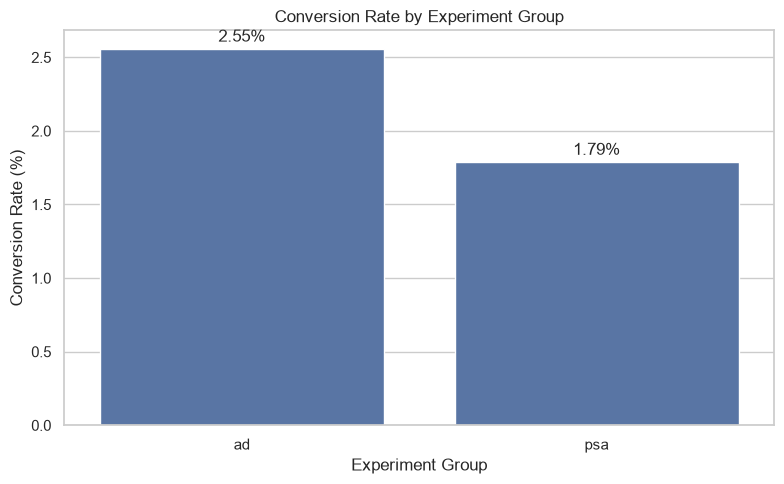

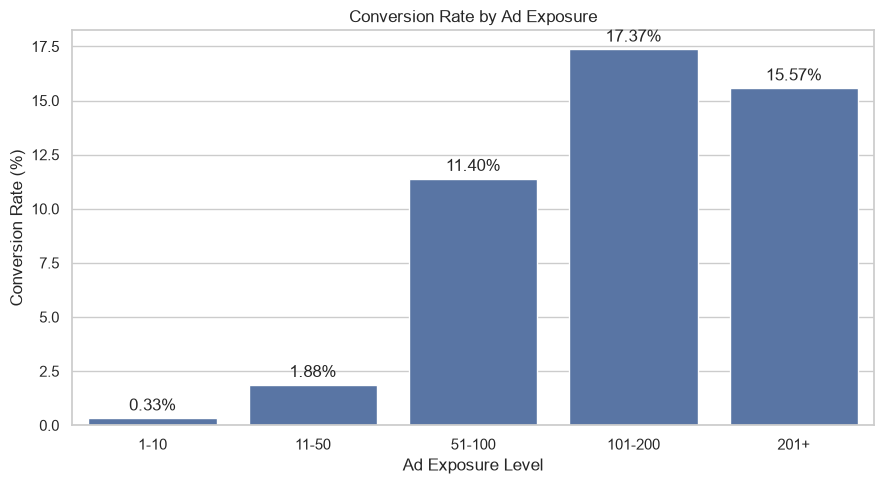

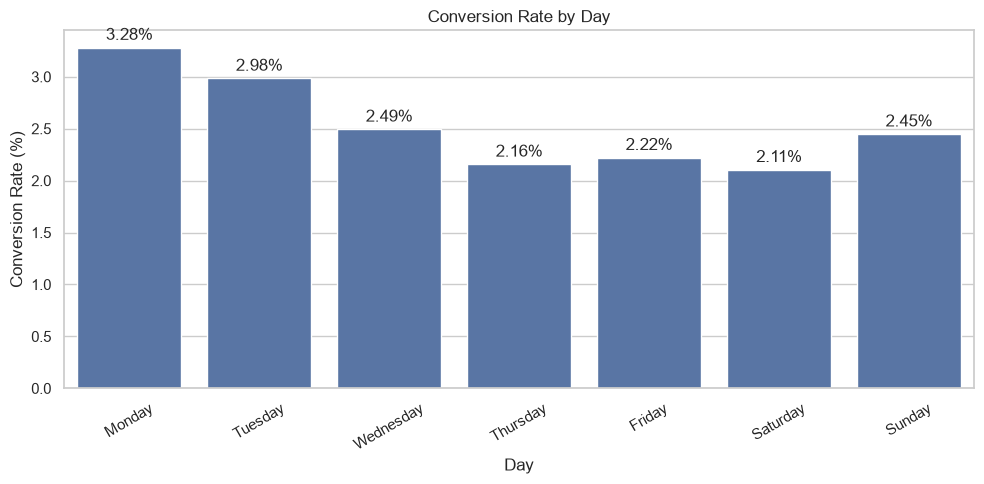

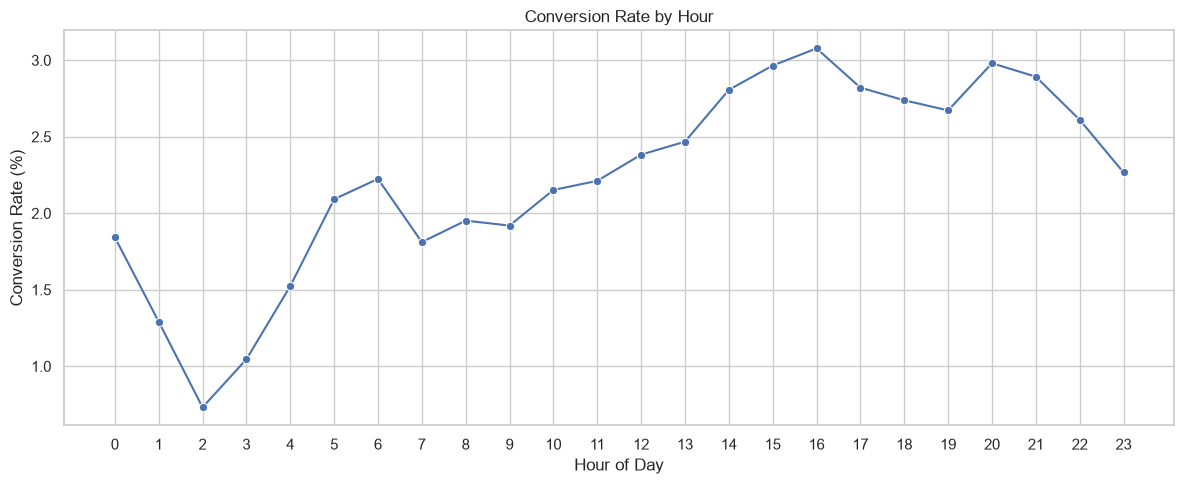

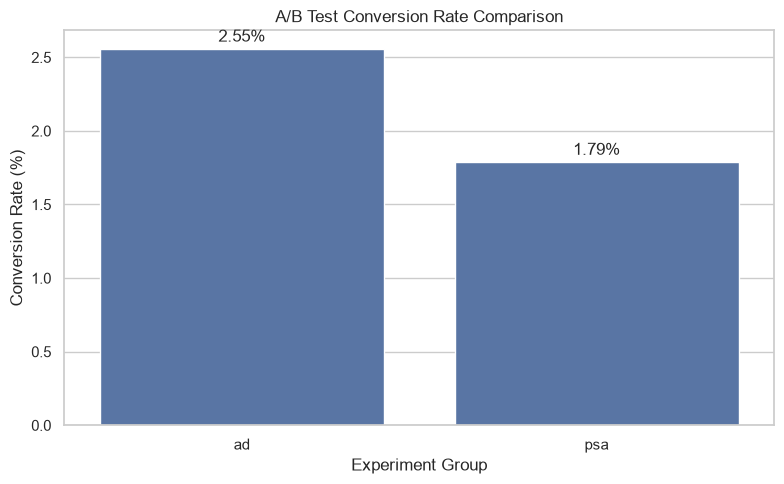


VISUALIZATIONS COMPLETED
Charts saved to:
../03_Visualizations/


In [18]:
# ============================================================
# 7. VISUALIZATIONS
# ============================================================


# ------------------------------------------------------------
# 7.1 VISUALIZATION SETUP
# ------------------------------------------------------------

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../01_Dataset/marketing_AB_cleaned.csv")

# Convert data types if required
if df["converted"].dtype == "object":
    df["converted"] = df["converted"].map({
        "True": True,
        "False": False,
        "true": True,
        "false": False
    })

# Create visualization folder
os.makedirs("../03_Visualizations", exist_ok=True)

# Visualization style
sns.set_theme(style="whitegrid")

print("Visualization dataset loaded successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Columns: {list(df.columns)}")


# ------------------------------------------------------------
# 7.2 CONVERSION RATE BY EXPERIMENT GROUP
# ------------------------------------------------------------

group_visual = (
    df.groupby("test_group")
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
)

group_visual["conversion_rate"] = (
    group_visual["conversions"] /
    group_visual["users"]
) * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=group_visual.index,
    y=group_visual["conversion_rate"]
)

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../03_Visualizations/01_conversion_rate_by_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7.3 CONVERSION RATE BY AD EXPOSURE
# ------------------------------------------------------------

df["ad_exposure_level"] = pd.cut(
    df["total_ads"],
    bins=[0, 10, 50, 100, 200, float("inf")],
    labels=["1-10", "11-50", "51-100", "101-200", "201+"]
)

exposure_visual = (
    df.groupby("ad_exposure_level", observed=True)
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
)

exposure_visual["conversion_rate"] = (
    exposure_visual["conversions"] /
    exposure_visual["users"]
) * 100

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=exposure_visual.index,
    y=exposure_visual["conversion_rate"]
)

plt.title("Conversion Rate by Ad Exposure")
plt.xlabel("Ad Exposure Level")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../03_Visualizations/02_conversion_rate_by_ad_exposure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7.4 CONVERSION RATE BY DAY
# ------------------------------------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_visual = (
    df.groupby("most_ads_day")
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
)

day_visual["conversion_rate"] = (
    day_visual["conversions"] /
    day_visual["users"]
) * 100

day_visual = day_visual.reindex(day_order)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=day_visual.index,
    y=day_visual["conversion_rate"]
)

plt.title("Conversion Rate by Day")
plt.xlabel("Day")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../03_Visualizations/03_conversion_rate_by_day.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7.5 CONVERSION RATE BY HOUR
# ------------------------------------------------------------

hour_visual = (
    df.groupby("most_ads_hour")
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
)

hour_visual["conversion_rate"] = (
    hour_visual["conversions"] /
    hour_visual["users"]
) * 100

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hour_visual.index,
    y=hour_visual["conversion_rate"],
    marker="o"
)

plt.title("Conversion Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Conversion Rate (%)")

plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    "../03_Visualizations/04_conversion_rate_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7.6 A/B TEST RESULT
# ------------------------------------------------------------

ab_visual = group_visual.loc[
    ["ad", "psa"]
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=ab_visual.index,
    y=ab_visual["conversion_rate"]
)

plt.title("A/B Test Conversion Rate Comparison")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../03_Visualizations/05_ab_test_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. VISUALIZATIONS COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("VISUALIZATIONS COMPLETED")
print("=" * 60)

print("Charts saved to:")
print("../03_Visualizations/")

## 8. Business Recommendations

### 8.1 Key Business Findings

- The **Ad group** achieved a conversion rate of **2.55%**, compared with **1.79%** for the PSA control group.
- The Ad group achieved an **absolute conversion-rate improvement of 0.77 percentage points**.
- The relative conversion lift was **43.09%** compared with the PSA group.
- The two-proportion Z-test showed that the difference was **statistically significant**.
- The **95% confidence interval** for the conversion-rate difference was approximately **0.60% to 0.94%**.
- **Monday** recorded the highest observed daily conversion rate at approximately **3.28%**.
- **16:00** recorded the highest observed hourly conversion rate at approximately **3.08%**.
- Conversion rates increased substatially with higher ad-exposure, reaching the highest observed rate in the **101–200 ads** exposure range.

### 8.2 Recommendation 1 - Prioritize the AD Campaign

The Ad campaign demonstrated significantly stronger conversion performance than the PSA control campaign.

**Recommendation:**

- Prioritize the Ad campaign over the PSA campaign.
- Use the Ad strategy as the preferred approach for future customer-acquisition experiments.
- Continue controlled experimentation before unrestricted scaling.

### 8.3 Recommendation 2 — Optimize AD Timing

Conversion performance varies across days and hours.

**Recommendation:**

- Test campaign activity during higher-performing periods.
- Monday showed the highest observed daily conversion rate.
- 16:00 showed the highest observed hourly conversion rate.
- Conduct controlled experiments to determine whether concentrating activity around these periods improves campaign efficiency.

### 8.4 Recommendation 3 — Optimize AD Exposure

Higher ad-exposure levels were associated with substantially higher observed conversion rates.

**Recommendation:**

- Investigate the **101–200 ads** exposure range as a potential high-performing segment.
- Do not assume that increasing exposure directly causes higher conversion.
- Run controlled experiments to identify an efficient exposure level.
- Monitor conversion performance together with customer engagement and campaign cost.

### 8.5 Recommendation 4 — Test New AD Creatives

The stronger performance of the Ad group indicates potential for further optimization of the advertising strategy.

**Recommendation:**

- Test different ad creatives.
- Experiment with alternative messaging and calls to action.
- Compare campaign formats through controlled A/B testing.
- Measure conversion rate, conversion lift, and statistical significance for each variation.

### 8.6 Recommendation 5 — Continue Controlled A/B Testing

The current experiment provides strong statistical evidence that the Ad group performs better than the PSA group.

**Recommendation:**

- Continue controlled A/B tests for future campaign changes.
- Test different targeting strategies, creatives, messaging, and exposure levels.
- Validate results across different customer segments and campaign periods.
- Use statistical evidence to support future product and marketing decisions.

### 8.7 Recommendation 6 — Monitor Campaign Cost

A higher conversion rate does not automatically mean higher profitability.

**Recommendation:**

- Monitor advertising spend alongside conversion performance.
- Track customer acquisition cost, revenue, and profitability when available.
- Evaluate return on advertising spend before unrestricted campaign scaling.
- Balance conversion gains with overall marketing efficiency.

### 8.8 Business Action Plan

| Priority | Action | Expected Outcome |
|---|---|---|
| High | Prioritize Ad campaign | Improve conversion performance |
| High | Test high-performing time periods | Improve campaign efficiency |
| High | Investigate optimal ad exposure | Identify efficient exposure level |
| Medium | Test new ad creatives | Improve engagement and conversion |
| Medium | Continue A/B testing | Support data-driven decisions |
| Medium | Monitor campaign cost | Balance conversion gains with efficiency |

### 8.9 Final Business Conclusion

The analysis indicates that the **Ad campaign is the stronger-performing strategy**.

With a conversion rate of **2.55% versus 1.79%**, the Ad group achieved approximately **43.09% relative conversion lift** over the PSA group.

The statistical significance test confirms that this difference is unlikely to be due to random variation alone.

Therefore, the business should **prioritize the Ad strategy while continuing controlled experimentation** to optimize campaign timing, ad exposure, creative content, and overall marketing efficiency.

### 8.10 Analytical Note

The relationship between ad exposure and conversion should be interpreted carefully.

Higher ad exposure is associated with higher observed conversion rates, but this analysis alone does not establish that increasing ad exposure causes higher conversion.

The A/B experiment provides evidence for the difference between the assigned Ad and PSA groups, while comparisons across exposure levels are primarily observational.

Further controlled experimentation is recommended before making decisions about increasing customer ad exposure.

## 9. Dataset Limitations

- The experiment groups have substantially different sample sizes.
- The dataset does not contain advertising spend or campaign cost.
- Revenue and profit information are unavailable.
- Customer acquisition cost and customer lifetime value are not available.
- The analysis measures conversion impact but cannot determine campaign profitability.